# Tarefa: Iris - Tuning dos parâmetros

## Etapa 1: Importação das bibliotecas

In [ ]:
!pip install skorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch.nn as nn
from skorch import NeuralNetClassifier
import torch
import torch.nn.functional as F
from sklearn.model_selection import GridSearchCV
torch.__version__

'2.8.0+cu126'

## Etapa 2: Base de dados

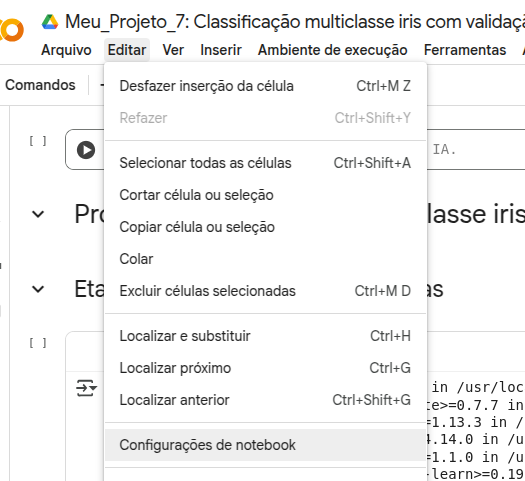

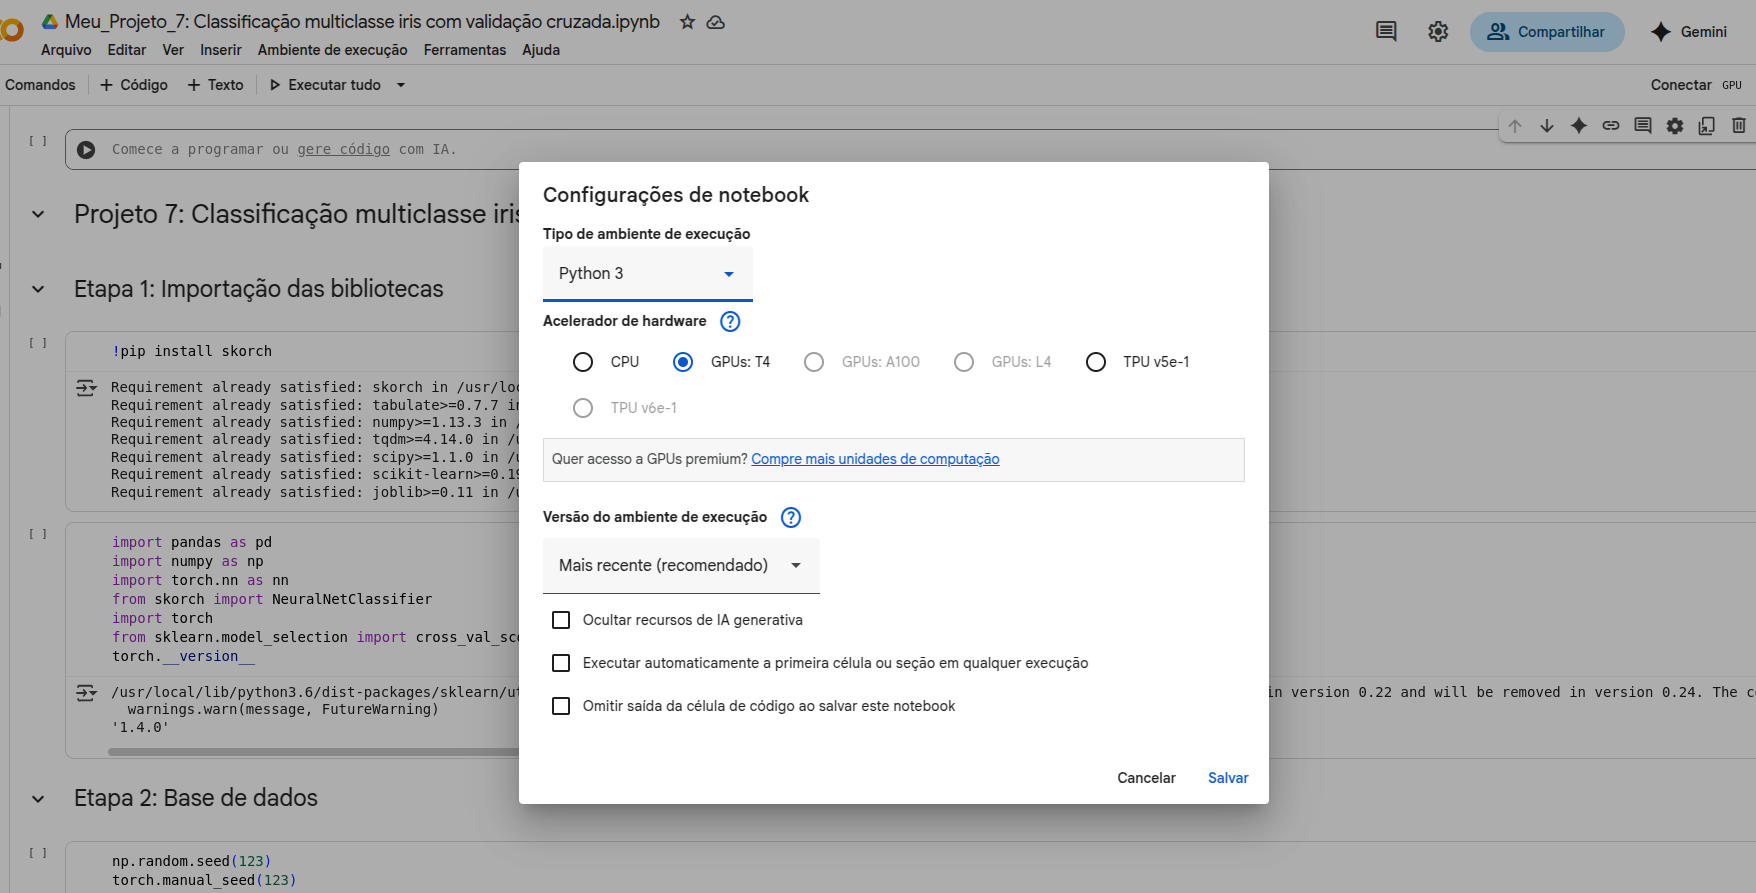

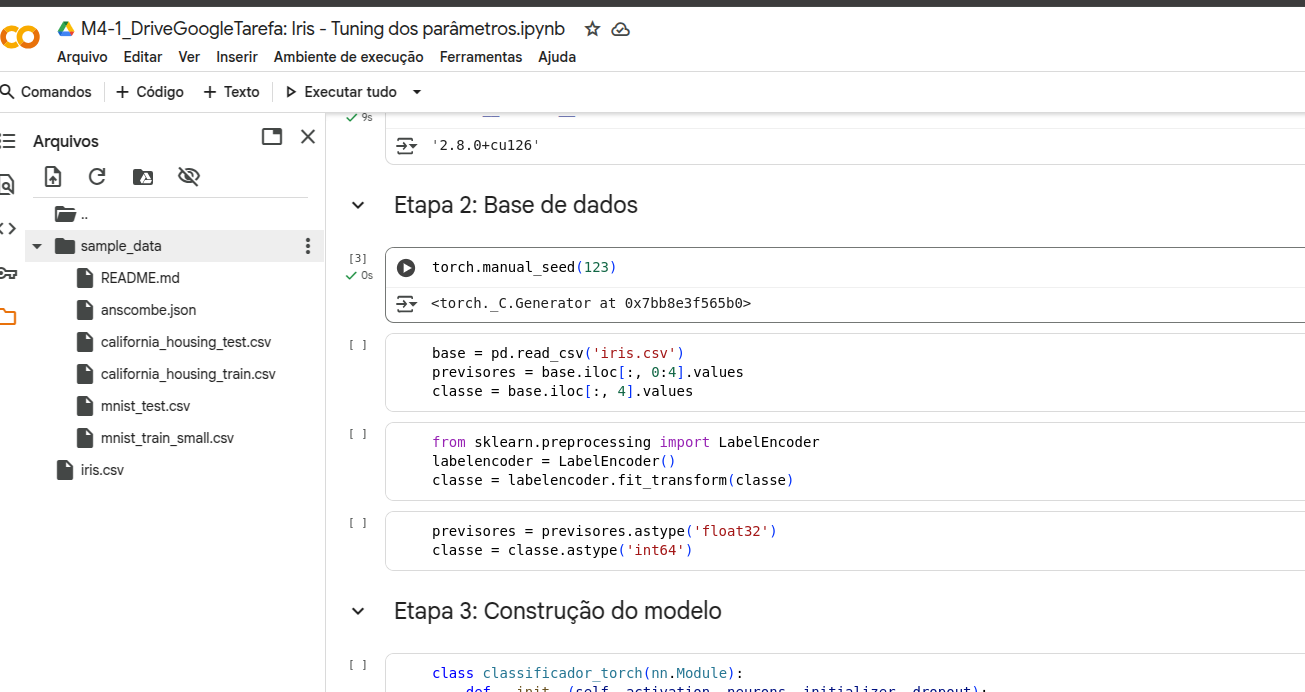

In [ ]:
# acima estão os processos de como rodamos dentro do drive e jupyter notebook o python.

In [ ]:
torch.manual_seed(123)

In [ ]:
base = pd.read_csv('iris.csv')
previsores = base.iloc[:, 0:4].values
classe = base.iloc[:, 4].values

In [ ]:
base.tail()

,sepal length,sepal width,petal length,petal width,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
classe = labelencoder.fit_transform(classe)

In [ ]:
previsores = previsores.astype('float32')
classe = classe.astype('int64')

### Fazer o ajuste (tuning) dos parâmetros utilizando validação cruzada e a técnica de busca em grade (grid search).


- O objetivo agora é descobrir quais são os melhores parâmetros para a base de dados Iris. Como essa base de dados possui somente 150 registros, o esforço computacional não será tão grande assim para chegarmos nos melhores valores.

Adicionar os seguintes elementos:

- Testar outros otimizadores, funções de ativação, inicializadores de pesos e número de neurônios nas camadas ocultas

- Adicionar camadas de dropout e passar como parâmetro os valores 0.2 e 0.3 para que o algoritmo descubra qual desses valores leva a melhor desempenho da rede neural

- Aumentar os valores do batch_size e do número de épocas (epochs )


## Etapa 3: Construção do modelo

In [ ]:
class classificador_torch(nn.Module):
    def __init__(self, activation, neurons, initializer, dropout):
        super().__init__()
        self.dense0 = nn.Linear(4, neurons)
        initializer(self.dense0.weight)
        self.activation0 = activation
        self.dense1 = nn.Linear(neurons, neurons)
        initializer(self.dense1.weight)
        self.activation1 = activation
        self.dense2 = nn.Linear(neurons, 3)

        self.dropout = nn.Dropout(dropout)

    def forward(self, X):
        X = self.dense0(X)
        X = self.activation0(X)
        X = self.dropout(X)
        X = self.dense1(X)
        X = self.activation1(X)
        X = self.dropout(X)
        X = self.dense2(X)
        return X

- Camadas Ocultas: Duas camadas densas (self.dense0 e self.dense1).

- Camada de Saída: Uma camada densa final (self.dense2) que gera 3 saídas.

- Função de Ativação: Uma função de ativação (self.activation0 e self.activation1) que adiciona não linearidade à rede.

- Dropout: Camadas de dropout (self.dropout) que ajudam a prevenir o overfitting.


init__ recebe parâmetros (activation, neurons, initializer, dropout), permitindo que nós configuremos a rede de forma dinâmica. Isso é perfeito para ser usado com técnicas como o Grid Search.


### Parâmetros

- activation: Define a função de ativação (como F.relu ou F.tanh) que será usada nas camadas.

- neurons: Controla o número de neurônios nas camadas ocultas.

- initializer: Define como os pesos da rede serão inicializados, o que pode influenciar a velocidade e a estabilidade do treinamento.

- dropout: Especifica a taxa de dropout, que é a porcentagem de neurônios que serão desativados aleatoriamente durante o treinamento para aumentar a robustez do modelo.

In [ ]:
classificador_sklearn = NeuralNetClassifier(module = classificador_torch,
                                            criterion = torch.nn.CrossEntropyLoss,
                                            train_split = False)

Cria um adaptador para o seu modelo de rede neural, permitindo que ele seja usado com as funções do scikit-learn.


- classificador_sklearn: Cria uma instância do <b>NeuralNetClassifier</b> da biblioteca skorch. Essa é a "ponte" entre o PyTorch e o scikit-learn.

- module = classificador_torch: Conecta o modelo de rede neural, que foi criado em PyTorch, a esse adaptador.

- criterion = torch.nn.CrossEntropyLoss: Define a função de perda (erro) que o modelo tentará minimizar. A CrossEntropyLoss é a função padrão e ideal para problemas de classificação.

- train_split = False: Este parâmetro instrui o skorch a não dividir os dados de treino automaticamente para validação. Isso é útil porque nós provavelmente usaremos as próprias ferramentas do scikit-learn para fazer a validação cruzada (como o cross_val_score que foi usado), e não precisa que a divisão seja feita duas vezes.

## Etapa 4: Tuning

In [ ]:
params = {'batch_size': [10, 30],
          'max_epochs': [200], ## [2000, 3000],
          'optimizer': [torch.optim.Adam, torch.optim.SGD],
          'module__activation': [F.relu, F.tanh, F.sigmoid],
          'module__neurons': [4, 8, 16],
          'module__initializer': [torch.nn.init.uniform_, torch.nn.init.normal_],
          'module__dropout': [0.2, 0.3]
          }

<b>params</b>: Este dicionário define o espaço de busca. Lista todos os valores que nós queremos testar para cada hiperparâmetro. O GridSearchCV vai iterar por cada uma das combinações possíveis.
Por exemplo, ele testará um modelo com batch_size de 10, max_epochs de 2000, optimizer Adam, activation F.relu, neurons 4, initializer uniform_ e dropout 0.2, e depois testará a próxima combinação, e assim por diante.

- GridSearchCV(...): Esta é a função do scikit-learn que executa a busca.

- estimator = classificador_sklearn: Este é o seu modelo de rede neural, que será treinado e testado.

- <b>param_grid = params</b>: A função sabe que deve usar o dicionário params para encontrar as combinações a serem testadas.

- <b>scoring = 'accuracy'</b>: Define a métrica de avaliação. Para cada combinação de hiperparâmetros, o GridSearchCV usará a acurácia para determinar quão bem o modelo performa.

- <b>cv = 3</b>: Indica o uso de validação cruzada com 3 folds. Para cada combinação, os dados serão divididos em 3 partes, e o modelo será treinado e testado três vezes. <b>A pontuação final para aquela combinação será a média da acurácia dessas 3 rodadas</b>.



In [ ]:
grid_search = GridSearchCV(estimator = classificador_sklearn,
                           param_grid = params,
                           scoring = 'accuracy',
                           cv = 3)

In [13]:
grid_search = grid_search.fit(previsores, classe)

A saída de streaming foi truncada nas últimas 5000 linhas.
     49        0.9077  0.0077
     50        0.8920  0.0071
     51        0.9199  0.0110
     52        0.9083  0.0070
     53        0.8694  0.0097
     54        0.8553  0.0063
     55        0.8678  0.0077
     56        0.8781  0.0106
     57        0.8288  0.0071
     58        0.8398  0.0070
     59        0.8747  0.0100
     60        0.7955  0.0073
     61        0.7932  0.0097
     62        0.8002  0.0064
     63        0.7601  0.0077
     64        0.7460  0.0070
     65        0.7494  0.0083
     66        0.7703  0.0061
     67        0.7527  0.0067
     68        0.7039  0.0074
     69        0.7155  0.0091
     70        0.7483  0.0171
     71        0.7078  0.0072
     72        0.7303  0.0122
     73        0.7221  0.0067
     74        0.6713  0.0069
     75        0.7034  0.0074
     76        0.6913  0.0147
     77        0.7176  0.0123
     78        0.6696  0.0085
     79        0.6588  0.0072
     80    

In [14]:
melhores_parametros = grid_search.best_params_
melhor_precisao = grid_search.best_score_

In [15]:
melhores_parametros

{'batch_size': 10,
 'max_epochs': 200,
 'module__activation': <function torch.nn.functional.relu(input: torch.Tensor, inplace: bool = False) -> torch.Tensor>,
 'module__dropout': 0.2,
 'module__initializer': <function torch.nn.init.uniform_(tensor: torch.Tensor, a: float = 0.0, b: float = 1.0, generator: Optional[torch._C.Generator] = None) -> torch.Tensor>,
 'module__neurons': 16,
 'optimizer': torch.optim.adam.Adam}

In [16]:
melhor_precisao

np.float64(0.98)